In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity

In [2]:
import os, getpass

if not os.getenv("PPLX_API_KEY"):
    os.environ["PPLX_API_KEY"] = getpass.getpass("PPLX_API_KEY: ")

PPLX_API_KEY:  ········


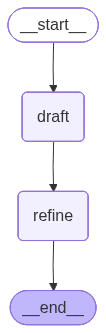

In [4]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langchain_perplexity import ChatPerplexity
from langgraph.graph import StateGraph, END

llm = ChatPerplexity(model="sonar-pro")

class ResearchState(TypedDict):
    topic: str
    question: str
    draft: str
    final: str

def draft(state: ResearchState) -> ResearchState:
    prompt = (
        "You are a research assistant.\n"
        "Topic: " + state["topic"] + "\n"
        "Question: " + state["question"] + "\n\n"
        "Write a helpful draft answer in two short paragraphs."
    )
    response = llm.invoke(prompt)
    return {
        "topic": state["topic"],
        "question": state["question"],
        "draft": response.content,
        "final": "",
    }

def refine(state: ResearchState) -> ResearchState:
    prompt = (
        "Rewrite the following into a clear 1–2 paragraph answer:\n\n"
        + state["draft"]
    )
    response = llm.invoke(prompt)
    return {
        "topic": state["topic"],
        "question": state["question"],
        "draft": state["draft"],
        "final": response.content,
    }

builder = StateGraph(ResearchState)
builder.add_node("draft", draft)
builder.add_node("refine", refine)

builder.set_entry_point("draft")
builder.add_edge("draft", "refine")
builder.add_edge("refine", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [6]:
state_1 = {
    "topic": "remote work",
    "question": "What are the benefits of remote work?",
    "draft": "",
    "final": "",
}

result_1 = graph.invoke(state_1)

print("FINAL ANSWER:")
print(result_1["final"])

FINAL ANSWER:
Remote work offers substantial benefits for both employees and employers. For workers, it provides greater flexibility and autonomy, allowing them to work from any location and tailor their schedules around personal commitments.[1] This flexibility has real value: 65% of workers are willing to trade part of their salary for flexible working hours, and nearly 40% of workers would start job hunting if this flexibility were taken away.[1] Remote workers also save significant commuting time—on average, full-time in-office and hybrid workers spend 31 minutes commuting each way, translating to considerable time that can be redirected toward personal well-being and productivity.[1] Additionally, remote work eliminates many office distractions, and employees at companies supporting remote or hybrid work report higher engagement, with 84% saying they can count on colleagues to cooperate compared to 65% in typical workplaces.[2]

From an organizational perspective, remote work deli

In [7]:
state_2 = {
    "topic": "sleep and learning",
    "question": "How does sleep affect memory?",
    "draft": "",
    "final": "",
}

result_2 = graph.invoke(state_2)

print("FINAL ANSWER:")
print(result_2["final"])

FINAL ANSWER:
Sleep plays a crucial role in consolidating and strengthening memories, making it essential for effective learning.[1][2] During sleep, the brain actively processes information and experiences from the day, transferring memories from short-term storage in the hippocampus to long-term storage in the cortex.[2] Different sleep stages contribute to memory formation in distinct ways: slow-wave NREM sleep early in the night helps transfer factual information to long-term storage, while late-night REM sleep is important for integrating procedural and spatial memories.[2] This consolidation process strengthens neural connections and pathways between brain cells, allowing memories to become stable and accessible for later recall.[1][4]

Sleep deprivation significantly impairs both learning and memory retention, with research showing that individuals deprived of sleep before learning experience approximately a 40% reduction in memory retention compared to those who slept normally.

In [8]:
state_3 = {
    "topic": "plastic pollution",
    "question": "What are long-term effects on marine ecosystems?",
    "draft": "",
    "final": "",
}

first = graph.invoke(state_3)

followup = llm.invoke(
    "Revise this answer to include effects on food chains and human health:\n\n"
    + first["final"]
)

print("UPDATED ANSWER:")
print(followup.content)

UPDATED ANSWER:
Plastic pollution creates severe, persistent ecological disruptions in marine ecosystems that persist for decades or longer due to plastic's resistance to degradation. The physical impacts on marine life are substantial and widespread—approximately 8 million tonnes of plastic waste enter the ocean annually[6], affecting marine species across all sizes. Marine animals suffer from entanglement in fishing gear and plastic debris[3], with entanglement and ingestion documented as impacting 914 megafaunal species, of which more than 100 are endangered[2]. Additionally, marine creatures ingest plastic fragments mistaken for food, leading to starvation, suffocation, and toxic contamination, with seabirds particularly vulnerable to mistaking small plastic fragments floating on the water's surface for food[3]. Plastic debris causes the deaths of more than a million seabirds each year[3].

## Effects on Marine Food Chains

Beyond direct physical harm, plastic creates long-term che

In [9]:
def research(topic: str, question: str) -> str:
    result = graph.invoke({
        "topic": topic,
        "question": question,
        "draft": "",
        "final": "",
    })
    return result["final"]

print(research("renewable energy", "Why is it important?"))

Renewable energy is essential for tackling climate change, environmental degradation, and energy security.[1][3][5] Unlike fossil fuels, renewable sources such as solar, wind, hydropower, and geothermal energy emit little to no greenhouse gases during operation, making them vital for reducing carbon emissions and air pollution that threaten planetary and human health.[2][3][5] Transitioning to renewables can substantially reduce the burden of environmental pollution-related illnesses while strengthening national energy independence by decreasing reliance on imported fuels, thereby protecting economies from geopolitical crises and volatile global energy markets.[2][5]

Beyond environmental benefits, renewable energy drives economic growth and social equity.[1][2] Renewable technologies have become cost-competitive with fossil fuels, with wind and solar now offering lower generation costs than new coal and natural gas plants, resulting in more affordable electricity for households and bu